In [ ]:
from google.colab import files

# This opens a file picker dialog
uploaded = files.upload()   # select your kaggle.json file here

Saving kaggle.json to kaggle.json


In [ ]:
import os, json, shutil

# Move to correct location
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# Verify
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "r") as f:
    content = json.load(f)
    print(f"Username : {content['username']}")
    print(f"Key len  : {len(content['key'])}")

Username : minal3009
Key len  : 32


In [ ]:
!kaggle competitions list | head -5

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured  2,207,152 Usd       3682           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  


In [ ]:
!kaggle competitions download -c histopathologic-cancer-detection -p ./pcam_raw

100% 6.31G/6.31G [00:52<00:00, 129MB/s]



In [ ]:
import zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DIR   = Path("./pcam_raw")
RAW_ZIP   = RAW_DIR / "histopathologic-cancer-detection.zip"
DATA_DIR  = Path("./pcam_data")

# Extract only labels CSV first (fast)
print("Extracting labels CSV...")
with zipfile.ZipFile(RAW_ZIP, 'r') as z:
    z.extract("train_labels.csv", DATA_DIR)

print("Done!")

Extracting labels CSV...
Done!


        FULL DATASET CLASS DISTRIBUTION
  Total samples      : 220,025
  Class 0 (Negative) : 130,908  (59.50%)
  Class 1 (Positive) : 89,117  (40.50%)
--------------------------------------------------
  Majority class     : Class 0 (130,908 samples)
  Minority class     : Class 1 (89,117 samples)
  Difference         : 41,791 samples
  After undersampling: 89,117 per class = 178,234 total


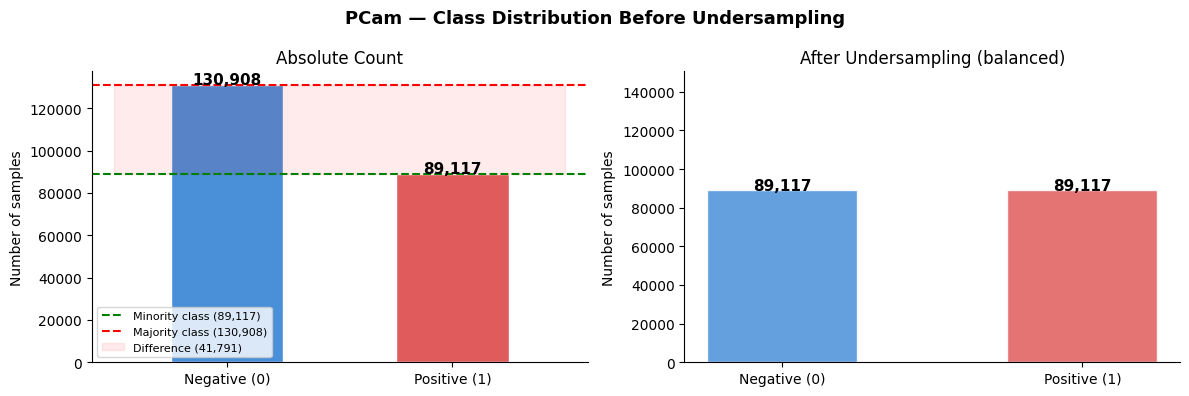

In [ ]:
df = pd.read_csv(DATA_DIR / "train_labels.csv")
df.columns = ['id', 'label']

# Class counts
counts    = df['label'].value_counts().sort_index()
n_neg     = counts[0]
n_pos     = counts[1]
majority  = counts.max()
minority  = counts.min()
majority_class = counts.idxmax()
minority_class = counts.idxmin()
difference = majority - minority

print("=" * 50)
print("        FULL DATASET CLASS DISTRIBUTION")
print("=" * 50)
print(f"  Total samples      : {len(df):,}")
print(f"  Class 0 (Negative) : {n_neg:,}  ({n_neg/len(df)*100:.2f}%)")
print(f"  Class 1 (Positive) : {n_pos:,}  ({n_pos/len(df)*100:.2f}%)")
print("-" * 50)
print(f"  Majority class     : Class {majority_class} ({majority:,} samples)")
print(f"  Minority class     : Class {minority_class} ({minority:,} samples)")
print(f"  Difference         : {difference:,} samples")
print(f"  After undersampling: {minority:,} per class = {minority*2:,} total")
print("=" * 50)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("PCam — Class Distribution Before Undersampling", fontsize=13, fontweight='bold')
colors = ['#4A90D9', '#E05C5C']

# Bar chart
ax1 = axes[0]
bars = ax1.bar(['Negative (0)', 'Positive (1)'], counts.values,
               color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax1.axhline(y=minority, color='green', linestyle='--',
            linewidth=1.5, label=f'Minority class ({minority:,})')
ax1.axhline(y=majority, color='red', linestyle='--',
            linewidth=1.5, label=f'Majority class ({majority:,})')
ax1.fill_between([-0.5, 1.5], minority, majority,
                 alpha=0.08, color='red', label=f'Difference ({difference:,})')
ax1.set_ylabel("Number of samples")
ax1.set_title("Absolute Count")
ax1.legend(fontsize=8)
ax1.spines[['top', 'right']].set_visible(False)

# After undersampling preview
ax2 = axes[1]
after_counts = [minority, minority]
bars2 = ax2.bar(['Negative (0)', 'Positive (1)'], after_counts,
                color=colors, width=0.5, edgecolor='white', alpha=0.85)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{minority:,}', ha='center', fontweight='bold', fontsize=11)
ax2.set_ylabel("Number of samples")
ax2.set_title(f"After Undersampling (balanced)")
ax2.set_ylim(0, majority * 1.15)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches='tight')
plt.show()


In [ ]:
# Undersample majority class to match minority class size
df_minority = df[df['label'] == minority_class]
df_majority = df[df['label'] == majority_class].sample(n=minority, random_state=42)

df_balanced = pd.concat([df_minority, df_majority]).sample(frac=1, random_state=42).reset_index(drop=True)

print("=" * 50)
print("        AFTER UNDERSAMPLING")
print("=" * 50)
print(f"  Total samples      : {len(df_balanced):,}")
print(f"  Class 0 (Negative) : {(df_balanced['label']==0).sum():,}")
print(f"  Class 1 (Positive) : {(df_balanced['label']==1).sum():,}")
print(f"  Removed            : {difference:,} samples from Class {majority_class}")
print("=" * 50)

# Save balanced labels
df_balanced.to_csv(DATA_DIR / "balanced_labels.csv", index=False)
print("\nBalanced labels saved to balanced_labels.csv")

        AFTER UNDERSAMPLING
  Total samples      : 178,234
  Class 0 (Negative) : 89,117
  Class 1 (Positive) : 89,117
  Removed            : 41,791 samples from Class 0

Balanced labels saved to balanced_labels.csv


In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("./pcam_data")

df = pd.read_csv(DATA_DIR / "balanced_labels.csv")

SAMPLES_PER_CLASS = 10000

df_subset = df.groupby('label').sample(
    n=SAMPLES_PER_CLASS,
    random_state=42
).sample(frac=1, random_state=42).reset_index(drop=True)

print("="*45)
print(f"  Total   : {len(df_subset):,}")
print(f"  Class 0 : {(df_subset['label']==0).sum():,}")
print(f"  Class 1 : {(df_subset['label']==1).sum():,}")
print("="*45)

df_subset.to_csv(DATA_DIR / "final_subset_labels.csv", index=False)
print("Saved → final_subset_labels.csv")

  Total   : 20,000
  Class 0 : 10,000
  Class 1 : 10,000
Saved → final_subset_labels.csv


In [ ]:
import zipfile
from tqdm import tqdm

RAW_ZIP   = Path("./pcam_raw/histopathologic-cancer-detection.zip")
TRAIN_DIR = DATA_DIR / "train"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

subset_ids = set(df_subset['id'].values)

print(f"Extracting {len(subset_ids):,} images from ZIP...")
print("This will take 3–5 minutes...")

extracted, skipped = 0, 0

with zipfile.ZipFile(RAW_ZIP, 'r') as z:
    all_files = z.namelist()
    train_files = [f for f in all_files if f.startswith("train/") and f.endswith(".tif")]

    for fpath in tqdm(train_files, desc="Scanning"):
        fname = Path(fpath).stem   # get ID without extension
        if fname in subset_ids:
            target = TRAIN_DIR / f"{fname}.tif"
            if not target.exists():
                z.extract(fpath, DATA_DIR)
                extracted += 1
            else:
                skipped += 1

print(f"\nExtracted : {extracted:,}")
print(f"Skipped   : {skipped:,} (already on disk)")
print(f"Total     : {extracted + skipped:,}")

Extracting 20,000 images from ZIP...
This will take 3–5 minutes...


Scanning: 100%|██████████| 220025/220025 [00:21<00:00, 10168.60it/s]


Extracted : 20,000
Skipped   : 0 (already on disk)
Total     : 20,000


In [ ]:
df_subset = pd.read_csv(DATA_DIR / "final_subset_labels.csv")

missing = []
for _, row in df_subset.iterrows():
    fp = TRAIN_DIR / f"{row['id']}.tif"
    if not fp.exists():
        missing.append(row['id'])

print("="*45)
print(f"  Total expected : {len(df_subset):,}")
print(f"  Found on disk  : {len(df_subset) - len(missing):,}")
print(f"  Missing        : {len(missing)}")
print("="*45)

if len(missing) == 0:
    print("  All images verified!")
else:
    print(f"  Re-extracting {len(missing)} missing images...")

  Total expected : 20,000
  Found on disk  : 20,000
  Missing        : 0
  All images verified!


In [ ]:
from sklearn.model_selection import train_test_split

df_subset['label_str'] = df_subset['label'].astype(str)
df_subset['filepath']  = df_subset['id'].apply(
    lambda x: str(TRAIN_DIR / f"{x}.tif")
)

# 70 / 15 / 15 stratified split
train_df, temp_df = train_test_split(
    df_subset,
    test_size=0.30,
    stratify=df_subset['label'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("="*45)
print("       DATASET SPLITS")
print("="*45)
print(f"  Train : {len(train_df):,}  "
      f"(Neg: {(train_df['label']==0).sum():,} | "
      f"Pos: {(train_df['label']==1).sum():,})")
print(f"  Val   : {len(val_df):,}   "
      f"(Neg: {(val_df['label']==0).sum():,}  | "
      f"Pos: {(val_df['label']==1).sum():,})")
print(f"  Test  : {len(test_df):,}   "
      f"(Neg: {(test_df['label']==0).sum():,}  | "
      f"Pos: {(test_df['label']==1).sum():,})")
print("="*45)

# Save splits
train_df.to_csv(DATA_DIR / "train_split.csv", index=False)
val_df.to_csv(DATA_DIR  / "val_split.csv",   index=False)
test_df.to_csv(DATA_DIR / "test_split.csv",  index=False)
print("Splits saved!")

       DATASET SPLITS
  Train : 14,000  (Neg: 7,000 | Pos: 7,000)
  Val   : 3,000   (Neg: 1,500  | Pos: 1,500)
  Test  : 3,000   (Neg: 1,500  | Pos: 1,500)
Splits saved!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE  = 224
BATCH     = 32

# ✅ ONLY NORMALIZATION
datagen = ImageDataGenerator(rescale=1./255)

# ── Train Generator ─────────────────────────
train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='binary',
    shuffle=True
)

# ── Validation Generator ────────────────────
val_gen = datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='binary',
    shuffle=False
)

# ── Test Generator ──────────────────────────
test_gen = datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label_str',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='binary',
    shuffle=False
)

print("="*45)
print("   DATA GENERATORS (NO AUGMENTATION)")
print("="*45)
print(f"  Train batches : {len(train_gen)}")
print(f"  Val batches   : {len(val_gen)}")
print(f"  Test batches  : {len(test_gen)}")
print(f"  Normalization : rescale = 1./255")
print("="*45)

Found 14000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.
Found 3000 validated image filenames belonging to 2 classes.
   DATA GENERATORS (NO AUGMENTATION)
  Train batches : 438
  Val batches   : 94
  Test batches  : 94
  Normalization : rescale = 1./255


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import DenseNet121
import numpy as np
import matplotlib.pyplot as plt
import time
import os

tf.keras.backend.clear_session()

# Verify GPU
print("="*45)
print(f"  TensorFlow version : {tf.__version__}")
print(f"  GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"  GPU device         : {gpus[0].name}")
print("="*45)

  TensorFlow version : 2.19.0
  GPU available      : True
  GPU device         : /physical_device:GPU:0


In [ ]:
def build_densenet121_transfer(input_shape=(224, 224, 3)):
    """
    DenseNet121 pretrained on ImageNet.

    Strategy:
      Phase 1 — Feature extraction: freeze all DenseNet layers, train only head
      Phase 2 — Fine tuning: unfreeze last 20 layers, train with low LR
    """

    # Load DenseNet121 without top classification layer
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Phase 1 — freeze entire base
    base_model.trainable = False

    # Build model
    inputs = tf.keras.Input(shape=input_shape)

    # IMPORTANT: keeps BatchNorm layers stable
    x = base_model(inputs, training=False)

    # ── Classification Head ──────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs, name="DenseNet121_TransferLearning")

    return model, base_model
    # Build & summarize
densenet_model, densenet_base = build_densenet121_transfer()
densenet_model.summary()

# Parameter analysis
total     = densenet_model.count_params()
trainable = sum([tf.size(w).numpy() for w in densenet_model.trainable_weights])
frozen    = total - trainable

print(f"\n  Total parameters     : {total:,}")
print(f"  Trainable parameters : {trainable:,}  ← only the head")
print(f"  Frozen parameters    : {frozen:,}   ← DenseNet121 base")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,333,953 (27.98 MB)

 Trainable params: 295,937 (1.13 MB)

 Non-trainable params: 7,038,016 (26.85 MB)


  Total parameters     : 7,333,953
  Trainable parameters : 295,937  ← only the head
  Frozen parameters    : 7,038,016   ← DenseNet121 base


In [ ]:
LEARNING_RATE = 1e-3
EPOCHS        = 15



# ── Compile DenseNet121 ─────────────────────────────────────────────
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print(f"  Optimizer     : Adam")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Loss          : Binary Crossentropy")
print(f"  Metrics       : Accuracy, AUC, Precision, Recall")

  Optimizer     : Adam
  Learning rate : 0.001
  Loss          : Binary Crossentropy
  Metrics       : Accuracy, AUC, Precision, Recall


In [ ]:
import os
os.makedirs("./model_checkpoints", exist_ok=True)

def get_callbacks(model_name):
    return [

        callbacks.ModelCheckpoint(
            filepath=f"./model_checkpoints/{model_name}_best.keras",
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),

        callbacks.EarlyStopping(
            monitor='val_auc',
            patience=5,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),

        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),

        callbacks.CSVLogger(
            f"./model_checkpoints/{model_name}_history.csv"
        )
    ]
densenet_callbacks = get_callbacks("densenet121")
print("Callbacks ready!")
print("  ModelCheckpoint → saves best model by val_auc")
print("  EarlyStopping   → stops if no improvement for 5 epochs")
print("  ReduceLROnPlateau → halves LR if val_loss plateaus")
print("  CSVLogger       → saves full history to CSV")

Callbacks ready!
  ModelCheckpoint → saves best model by val_auc
  EarlyStopping   → stops if no improvement for 5 epochs
  ReduceLROnPlateau → halves LR if val_loss plateaus
  CSVLogger       → saves full history to CSV


In [ ]:
print("="*50)
print("   TRAINING — DenseNet121 (Phase 1: Feature Extraction)")
print("="*50)

start_time = time.time()

densenet_history_phase1 = densenet_model.fit(
    train_gen,
    epochs=10,   # first phase
    validation_data=val_gen,
    callbacks=densenet_callbacks,
    verbose=1
)

phase1_time = time.time() - start_time
print(f"\nPhase 1 complete! Time: {phase1_time/60:.1f} minutes")

   TRAINING — DenseNet121 (Phase 1: Feature Extraction)
Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7745 - auc: 0.8517 - loss: 0.5175 - precision: 0.7871 - recall: 0.7479
Epoch 1: val_auc improved from None to 0.93404, saving model to ./model_checkpoints/densenet121_best.keras

Epoch 1: finished saving model to ./model_checkpoints/densenet121_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 116s 193ms/step - accuracy: 0.8023 - auc: 0.8822 - loss: 0.4487 - precision: 0.8133 - recall: 0.7847 - val_accuracy: 0.8497 - val_auc: 0.9340 - val_loss: 0.3580 - val_precision: 0.8120 - val_recall: 0.9100 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8311 - auc: 0.9129 - loss: 0.3770 - precision: 0.8396 - recall: 0.8206
Epoch 2: val_auc improved from 0.93404 to 0.93683, saving model to ./model_checkpoints/densenet121_best.keras

Epoch 2: finished saving model to ./model_checkpoints/densenet121_best.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 42s 96

In [ ]:
print("="*50)
print("   DenseNet121 Phase 2 — Fine Tuning")
print("="*50)

densenet_base.trainable = True

for layer in densenet_base.layers[:-20]:
    layer.trainable = False

trainable_now = sum([tf.size(w).numpy() for w in densenet_model.trainable_weights])
print(f"  Trainable parameters now : {trainable_now:,}")

densenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

start_time = time.time()

densenet_history_phase2 = densenet_model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen,
    callbacks=densenet_callbacks,
    verbose=1
)

phase2_time = time.time() - start_time
print(f"\nPhase 2 complete! Time: {phase2_time/60:.1f} minutes")
print(f"Total DenseNet time : {(phase1_time + phase2_time)/60:.1f} minutes")

   DenseNet121 Phase 2 — Fine Tuning
  Trainable parameters now : 663,105
Epoch 1/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8486 - auc: 0.9261 - loss: 0.3444 - precision: 0.8778 - recall: 0.8098
Epoch 1: val_auc did not improve from 0.94805
438/438 ━━━━━━━━━━━━━━━━━━━━ 117s 193ms/step - accuracy: 0.8541 - auc: 0.9314 - loss: 0.3338 - precision: 0.8802 - recall: 0.8197 - val_accuracy: 0.8687 - val_auc: 0.9404 - val_loss: 0.3094 - val_precision: 0.8961 - val_recall: 0.8340 - learning_rate: 1.0000e-05
Epoch 2/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8636 - auc: 0.9397 - loss: 0.3145 - precision: 0.8866 - recall: 0.8347
Epoch 2: val_auc did not improve from 0.94805
438/438 ━━━━━━━━━━━━━━━━━━━━ 50s 113ms/step - accuracy: 0.8626 - auc: 0.9376 - loss: 0.3177 - precision: 0.8857 - recall: 0.8326 - val_accuracy: 0.8723 - val_auc: 0.9425 - val_loss: 0.3032 - val_precision: 0.8919 - val_recall: 0.8473 - learning_rate: 1.0000e-05
Epoch 3/5
438/438 ━━━━━━━━━━━━━━━━

In [ ]:
def plot_training_curves(history, model_name, color):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{model_name} — Training Curves", fontsize=13, fontweight='bold')

    metrics = [('accuracy', 'Accuracy'), ('loss', 'Loss'), ('auc', 'AUC')]

    for ax, (metric, label) in zip(axes, metrics):
        ax.plot(history.history[metric], color=color, linewidth=2, label='Train')
        ax.plot(history.history[f'val_{metric}'], color=color, linestyle='--', alpha=0.7, label='Validation')
        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()


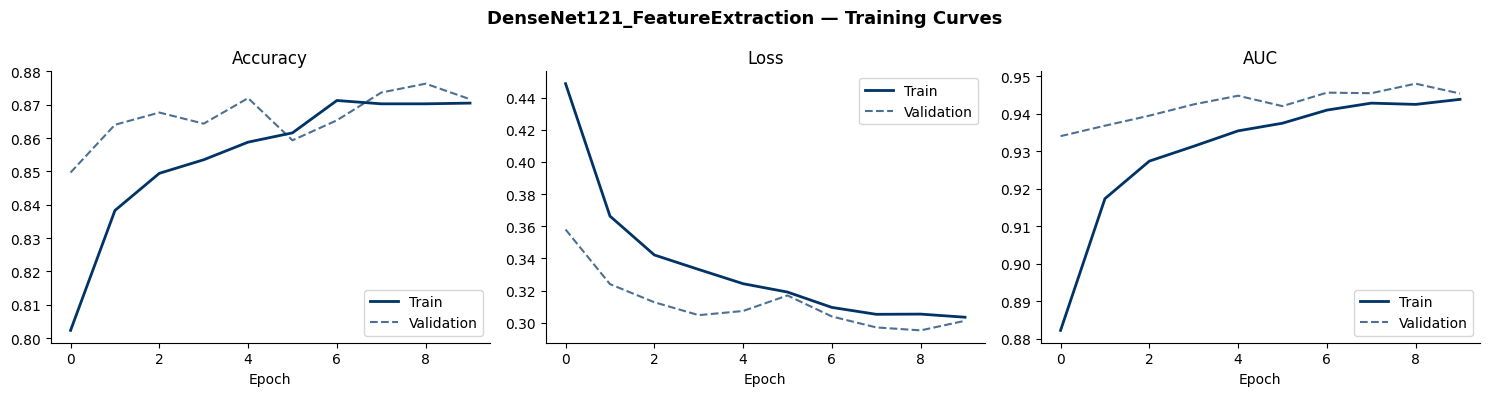

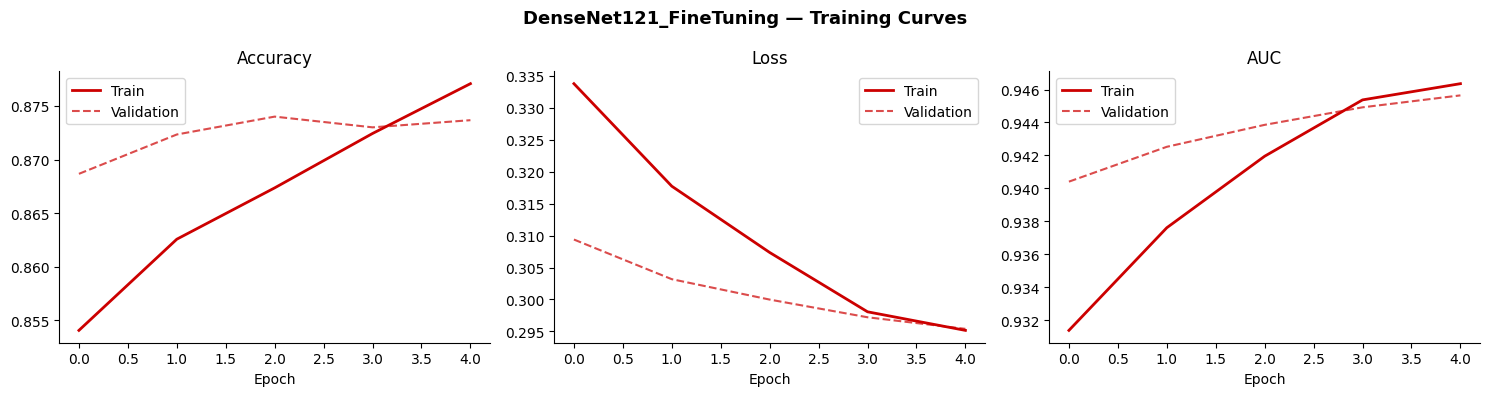

In [ ]:
# Phase 1 — Dark Blue
plot_training_curves(
    densenet_history_phase1,
    "DenseNet121_FeatureExtraction",
    '#003366'   # Dark Blue
)

# Phase 2 — Red
plot_training_curves(
    densenet_history_phase2,
    "DenseNet121_FineTuning",
    '#cc0000'   # Red
)

In [ ]:
# ── DenseNet Final Evaluation Comparison(Validation Set)  ─────────────────

print("\n" + "="*75)
print("        DENSENET121 — FINAL PERFORMANCE COMPARISON")
print("="*75)

# Get best epoch indices
fe_best_epoch = densenet_history_phase1.history['val_auc'].index(max(densenet_history_phase1.history['val_auc']))
ft_best_epoch = densenet_history_phase2.history['val_auc'].index(max(densenet_history_phase2.history['val_auc']))

# Feature Extraction (best epoch)
fe_acc  = densenet_history_phase1.history['val_accuracy'][fe_best_epoch]
fe_auc  = densenet_history_phase1.history['val_auc'][fe_best_epoch]
fe_prec = densenet_history_phase1.history['val_precision'][fe_best_epoch]
fe_rec  = densenet_history_phase1.history['val_recall'][fe_best_epoch]
fe_loss = densenet_history_phase1.history['val_loss'][fe_best_epoch]

# Fine-Tuning (best epoch)
ft_acc  = densenet_history_phase2.history['val_accuracy'][ft_best_epoch]
ft_auc  = densenet_history_phase2.history['val_auc'][ft_best_epoch]
ft_prec = densenet_history_phase2.history['val_precision'][ft_best_epoch]
ft_rec  = densenet_history_phase2.history['val_recall'][ft_best_epoch]
ft_loss = densenet_history_phase2.history['val_loss'][ft_best_epoch]

# Header
print(f"{'Metric':<20} {'Feature Extraction':<25} {'Fine-Tuning':<25}")
print("-"*75)

# Values
print(f"{'Accuracy':<20} {fe_acc:.4f}{'':<15} {ft_acc:.4f}")
print(f"{'AUC':<20} {fe_auc:.4f}{'':<15} {ft_auc:.4f}")
print(f"{'Precision':<20} {fe_prec:.4f}{'':<15} {ft_prec:.4f}")
print(f"{'Recall':<20} {fe_rec:.4f}{'':<15} {ft_rec:.4f}")
print(f"{'Loss':<20} {fe_loss:.4f}{'':<15} {ft_loss:.4f}")

print("="*75)

# Print epochs
print(f"\nBest Epoch (Feature Extraction): {fe_best_epoch + 1}")
print(f"Best Epoch (Fine-Tuning)      : {ft_best_epoch + 1}")


        DENSENET121 — FINAL PERFORMANCE COMPARISON
Metric               Feature Extraction        Fine-Tuning              
---------------------------------------------------------------------------
Accuracy             0.8763                0.8737
AUC                  0.9481                0.9456
Precision            0.9166                0.8944
Recall               0.8280                0.8473
Loss                 0.2953                0.2954

Best Epoch (Feature Extraction): 9
Best Epoch (Fine-Tuning)      : 5


94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step

     DENSENET121 — VALIDATION vs TEST (Fine-Tuned)
Metric               Validation           Test
------------------------------------------------------------
Accuracy             0.8687           0.8603
AUC                  0.9404           0.9358
Precision            0.8961           0.8914
Recall               0.8340           0.8207
F1-Score             0.8640           0.8546
Specificity          0.9033           0.9000

     DENSENET121 — FEATURE EXTRACTION vs FINE-TUNING (Val → Test)
Metric               Feature Extraction        Fine-Tuning
----------------------------------------------------------------------
  Accuracy           0.8763                0.8737   ← Validation
  AUC                0.9481                0.9456   ← Validation
  Precision          0.9166                0.8944   ← Validation
  Recall             0.8280                0.8473   ← Validation
----------------------------------------------------------------------


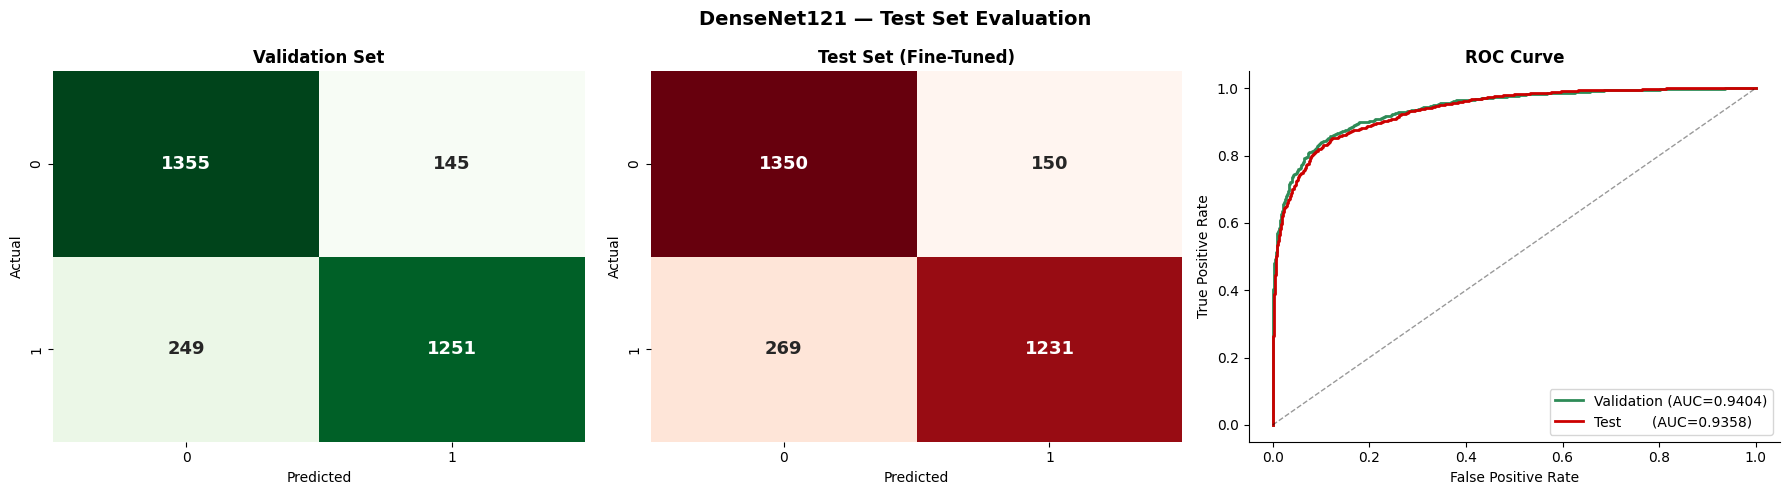


✅ Done! Plot saved as densenet121_test_evaluation.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#   DENSENET121 — TEST SET EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Get Test Predictions (Fine-Tuned model = current densenet_model) ──────────
test_gen.reset()
ft_prob = densenet_model.predict(test_gen, steps=len(test_gen), verbose=1).flatten()
ft_pred = (ft_prob >= 0.5).astype(int)
ft_true = test_gen.labels

# ── Get Validation Predictions (for comparison) ───────────────────────────────
val_gen.reset()
val_prob = densenet_model.predict(val_gen, steps=len(val_gen), verbose=0).flatten()
val_pred = (val_prob >= 0.5).astype(int)
val_true = val_gen.labels

# ── Helper: compute all metrics ───────────────────────────────────────────────
def get_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'acc'  : accuracy_score(y_true, y_pred),
        'auc'  : roc_auc_score(y_true, y_prob),
        'prec' : precision_score(y_true, y_pred, zero_division=0),
        'rec'  : recall_score(y_true, y_pred, zero_division=0),
        'f1'   : f1_score(y_true, y_pred, zero_division=0),
        'spec' : tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'cm'   : cm
    }

val_m = get_metrics(val_true, val_pred, val_prob)
ft_m  = get_metrics(ft_true,  ft_pred,  ft_prob)

# ══════════════════════════════════════════════════════════════════════════════
#   COMPARISON TABLE — Validation vs Test
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("     DENSENET121 — VALIDATION vs TEST (Fine-Tuned)")
print("="*60)
print(f"{'Metric':<20} {'Validation':<20} {'Test'}")
print("-"*60)
print(f"{'Accuracy':<20} {val_m['acc']:.4f}{'':>10} {ft_m['acc']:.4f}")
print(f"{'AUC':<20} {val_m['auc']:.4f}{'':>10} {ft_m['auc']:.4f}")
print(f"{'Precision':<20} {val_m['prec']:.4f}{'':>10} {ft_m['prec']:.4f}")
print(f"{'Recall':<20} {val_m['rec']:.4f}{'':>10} {ft_m['rec']:.4f}")
print(f"{'F1-Score':<20} {val_m['f1']:.4f}{'':>10} {ft_m['f1']:.4f}")
print(f"{'Specificity':<20} {val_m['spec']:.4f}{'':>10} {ft_m['spec']:.4f}")
print("="*60)

# ══════════════════════════════════════════════════════════════════════════════
#   FEATURE EXTRACTION vs FINE-TUNING — Test Set (from history best epoch)
# ══════════════════════════════════════════════════════════════════════════════

fe_best = densenet_history_phase1.history['val_auc'].index(
              max(densenet_history_phase1.history['val_auc']))
ft_best = densenet_history_phase2.history['val_auc'].index(
              max(densenet_history_phase2.history['val_auc']))

print("\n" + "="*70)
print("     DENSENET121 — FEATURE EXTRACTION vs FINE-TUNING (Val → Test)")
print("="*70)
print(f"{'Metric':<20} {'Feature Extraction':<25} {'Fine-Tuning'}")
print("-"*70)

fe_h = densenet_history_phase1.history
ft_h = densenet_history_phase2.history

rows = [
    ('Accuracy',    'val_accuracy',  val_m['acc'],  ft_m['acc']),
    ('AUC',         'val_auc',       val_m['auc'],  ft_m['auc']),
    ('Precision',   'val_precision', val_m['prec'], ft_m['prec']),
    ('Recall',      'val_recall',    val_m['rec'],  ft_m['rec']),
]

for label, key, _, _ in rows:
    fe_val = fe_h[key][fe_best]
    ft_val = ft_h[key][ft_best]
    print(f"  {label:<18} {fe_val:.4f}{'':>15} {ft_val:.4f}   ← Validation")

print("-"*70)
print(f"  {'Accuracy':<18} {'  —  ':<20} {ft_m['acc']:.4f}   ← Test (Fine-Tuned)")
print(f"  {'AUC':<18} {'  —  ':<20} {ft_m['auc']:.4f}   ← Test (Fine-Tuned)")
print(f"  {'F1-Score':<18} {'  —  ':<20} {ft_m['f1']:.4f}   ← Test (Fine-Tuned)")
print(f"  {'Specificity':<18} {'  —  ':<20} {ft_m['spec']:.4f}   ← Test (Fine-Tuned)")
print("="*70)

# ══════════════════════════════════════════════════════════════════════════════
#   PLOTS — Confusion Matrices + ROC Curve
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_curve
class_names = list(test_gen.class_indices.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DenseNet121 — Test Set Evaluation", fontsize=14, fontweight='bold')

# Confusion Matrix — Validation
sns.heatmap(val_m['cm'], annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar=False, annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title("Validation Set", fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Confusion Matrix — Test
sns.heatmap(ft_m['cm'], annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar=False, annot_kws={"size": 13, "weight": "bold"})
axes[1].set_title("Test Set (Fine-Tuned)", fontweight='bold')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

# ROC Curve
fpr_val, tpr_val, _ = roc_curve(val_true, val_prob)
fpr_ft,  tpr_ft,  _ = roc_curve(ft_true,  ft_prob)

axes[2].plot(fpr_val, tpr_val, color='#2e8b57', lw=2,
             label=f"Validation (AUC={val_m['auc']:.4f})")
axes[2].plot(fpr_ft,  tpr_ft,  color='#cc0000', lw=2,
             label=f"Test       (AUC={ft_m['auc']:.4f})")
axes[2].plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve", fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("densenet121_test_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Done! Plot saved as densenet121_test_evaluation.png")